# When America sneezes, does the world really catch a cold? 🌏
### Today's Wall Street close predicts tomorrow's Tokyo — hugely, reliably, for 30 years. And you still can't make a dime on it.

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Survives_algo_era%3F: Confirmed](https://img.shields.io/badge/Survives_algo_era%3F-Confirmed-8b949e?style=flat-square)

Here's the setup. New York closes at 4pm. **Three hours later, Tokyo opens.** Then Sydney trades, then Frankfurt and London the next morning — all *before* New York opens again. So every overseas market starts its day already knowing exactly what the US just did.

The old traders' line — *"America sneezes, the world catches a cold"* — claims those markets don't just know it, they **follow** it: a green day in New York means a green morning in Tokyo. Unlike most folklore on this desk, this one has three decades of academic paper behind it. We put it on the tape: 29.5 years, four countries, and an honest attempt to actually **trade** it.

> 📓 **Plain-language layer.** Want the HAC *t*-stats, the gap decomposition and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Data note up front.** SPY is total-return; the four overseas indices are price-only levels. Yahoo's index *opens* are stale on many days (we flag and exclude them wherever an open matters). Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from us_leads_the_world import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    BARS = data.load_real()
    PAIRS = data.build_all_pairs(BARS)
    BK = data.basket_pairs(PAIRS)
else:
    BARS = PAIRS = BK = None
print("real tape cached:", HAVE_REAL,
      "| aligned pairs:", (0 if PAIRS is None else {k: len(v) for k, v in PAIRS.items()}))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '1997-01-02', 'end': '2026-06-30', 'years': 29.5, 'asof': '2026-06-30', 'fingerprint': 'c6ad53f6345c', 'cc': {'^N225': ('Nikkei 225 (Tokyo)', 0.561, 19.59, 20.0, 7415), '^GDAXI': ('DAX (Frankfurt)', 0.222, 9.21, 3.5, 7417), '^FTSE': ('FTSE 100 (London)', 0.23, 10.5, 6.2, 7417), '^AXJO': ('ASX 200 (Sydney)', 0.387, 11.18, 23.2, 7417)}, 'basket': (0.35, 14.85, 19.5, 7417), 'placebo': (0.007, 0.75, 50), 'mech': {'^N225': (0.368, 21.15, 38.2, 0.193, 6.66, 4.1, 66, 100), '^GDAXI': (0.158, 6.94, 8.6, 0.066, 4.11, 0.4, 71, 100), '^FTSE': (0.139, 7.56, 23.2, 0.147, 5.05, 2.9, 60, 12), '^AXJO': (0.194, 14.67, 27.0, 0.251, 16.53, 16.5, 50, 59)}, 'eras': [('1997-2003', 0.336, 17.56, 1760), ('2004-2010', 0.41, 15.88, 1763), ('2011-2017', 0.429, 10.99, 1761), ('2018-2026', 0.266, 4.49, 2133)], 'size': [('Q1', 0.09, 0.322, 1.83), ('Q2', 0.29, 0.259, 4.37), ('Q3', 0.57, 0.407, 10.46), ('Q4', 0.97, 0.38, 15.57), ('Q5', 2.18, 0.343, 12.51)], 'prepost': {'^N225': (0.544, 16.2, 0.584, 11.5, -0.66), '^GDAXI': (0.247, 9.0, 0.19, 4.7, 1.16), '^FTSE': (0.289, 13.5, 0.154, 4.7, 3.42), '^AXJO': (0.411, 21.3, 0.356, 5.0, 0.74), 'GLOBAL4': (0.373, 21.4, 0.321, 7.1, 1.06)}, 'feasible': {'^N225': (9.5, 7.22, 7386, -0.5, -10.5), '^GDAXI': (5.0, 3.58, 7381, -5.0, -15.0), '^AXJO': (22.8, 16.4, 4392, 12.8, 2.8)}, 'phantom': {'^N225': (48.2, 27.59), '^GDAXI': (20.9, 12.76), '^FTSE': (18.7, 14.06), '^AXJO': (35.3, 27.22)}, 'syn': [(0.0, 0.003, 0.25), (0.35, 0.354, 25.82)], 'stale': {'^FTSE': 88, '^AXJO': 41}}


real tape cached: True | aligned pairs: {'^N225': 7415, '^GDAXI': 7417, '^FTSE': 7417, '^AXJO': 7417}


## The answer first

| Question | Answer |
|---|---|
| Does tomorrow's Tokyo follow today's New York? | **Massively.** A +1% US day moves the next Tokyo session about **+0.56%** on average — and the same holds (smaller) in Sydney, Frankfurt and London. This is one of the strongest, cleanest effects on our whole bench. |
| Hasn't 30 years of arbitrage killed it? | **No.** The 2018–2026 slice is as decisive as the 1990s. It *can't* be arbitraged away — and understanding why is the whole story. |
| So… free money? | **None.** Two-thirds of the move happens **at the opening print** — a price that exists before any order can fill. What's left after the open is thinner than the cost of trading it. |
| Can't I just buy the Japan ETF (EWJ) in New York? | **That's the trap.** EWJ trades *during US hours* — by your first chance to buy it, it has already moved with the US market, same day. The time zone that creates the prediction is what the wrapper removes. |

> A rare verdict: the folklore is **completely true** and **completely untradable** at the same time.

## 1 · The claim

> *"The US is the world's market leader. Tokyo, Sydney, Frankfurt and London open after New York closes — and they open the way New York closed. Yesterday's S&P is this morning's Nikkei."*

This isn't just folklore — it's **Hamao, Masulis & Ng (1990)**, **Becker, Finnerty & Gupta (1990)** and, in its modern form, **Rapach, Strauss & Zhou (2013, Journal of Finance)**: lagged US returns predict essentially every other country's market, and almost nothing predicts the US back. The mechanism is brutally simple: **the trading day itself is staggered around the globe**, so US news is always "yesterday's news" that the rest of the world hasn't traded yet.

The interesting question was never *whether* the correlation exists — it's whether the **time-zone spillover survives honestly measured, and whether anyone can eat it**.

## 2 · So what?

If this is real, every morning briefing that starts with "US stocks rose overnight, expect Asian shares to open higher" is *statistically justified* — not filler. And if it were tradable, it would be the simplest strategy on Earth: read the US close, buy Tokyo three hours later.

The catch we're hunting: **where exactly** does the follow-through happen? If it lands in the *opening price itself*, then the market has priced the US news before you can click — prediction without profit. That single distinction (the **gap** vs the **rest of the day**) decides whether this is an edge or just a fact of geography.

## 3 · How would we even know?

We take **30 years** of daily bars (1997-01-02 → 2026-06-30): **SPY** for the US, and the four big overseas indices — **Nikkei 225** (Tokyo), **ASX 200** (Sydney), **DAX** (Frankfurt), **FTSE 100** (London). For each US day *t* we find each market's **first session strictly after** that date (Tokyo opens ~7pm ET the same evening; Europe the next morning) and ask three things:

1. **Follow-through.** Does the next overseas session move with the US day? (A slope: overseas-% per US-%.)
2. **Where it lands.** Split each overseas day into the **opening gap** (last close → open, printed before anyone can trade) and the **open→close** part (the only piece a trader can own).
3. **The only real trade.** Follow the US sign at the next overseas *open*, sell at its close, pay costs — and see what's left.

## 4 · The teardown — let's actually look

**First, the follow-through.** How much does each market's next session move per 1% of US day?

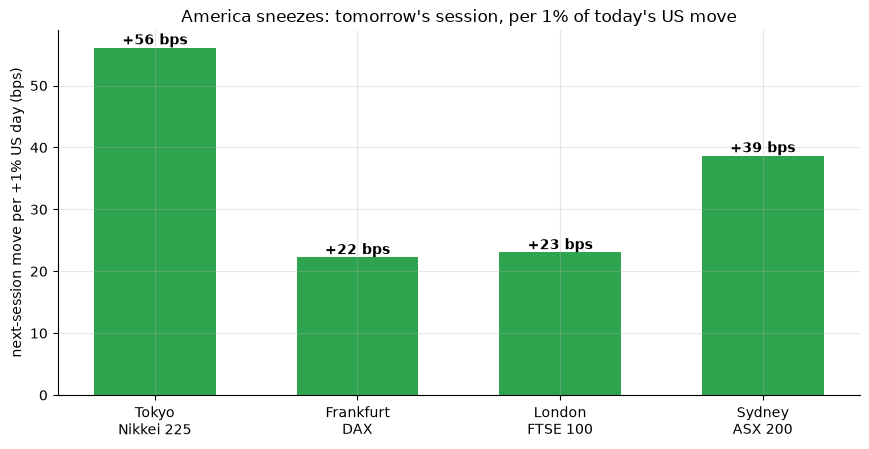

{'^N225': '+0.561', '^GDAXI': '+0.222', '^FTSE': '+0.230', '^AXJO': '+0.387'}


In [2]:
if HAVE_REAL:
    vals = {tk: st.ols_hac(p['us'], p['cc'])['slope'] for tk, p in PAIRS.items()}
else:
    vals = {tk: v[1] for tk, v in R['cc'].items()}
labels = [R['cc'][tk][0].split(' (')[1][:-1] + '\n' + R['cc'][tk][0].split(' (')[0] for tk in vals]
fig, ax = plt.subplots(figsize=(8.8, 4.6))
ax.bar(labels, [v*100 for v in vals.values()], color=GREEN, width=.6)
for i, v in enumerate(vals.values()):
    ax.annotate(f'+{v*100:.0f} bps', (i, v*100), ha='center', va='bottom', fontweight='bold')
ax.set_ylabel('next-session move per +1% US day (bps)')
ax.set_title('America sneezes: tomorrow\'s session, per 1% of today\'s US move')
plt.tight_layout(); plt.show()
print({k: f'+{v:.3f}' for k, v in vals.items()})

A +1% US day is followed, on average, by **+56 bps in Tokyo**, +39 in Sydney, +23 in London and +22 in Frankfurt. The quants notebook shows these are about as far from luck as market statistics ever get (odds-of-fluke *t*-scores of **9 to 20**; the desk's bar is 2). And it hasn't faded: the 2018–2026 slice alone still clears the bar easily (t = 4.5).

So the folklore is *true*. Now the important chart.

**Where does the move happen?** Each overseas day = the **opening gap** (printed before anyone can trade) + the **rest of the day** (what a trader can actually own). If the gap eats the spillover, the prediction is worthless.

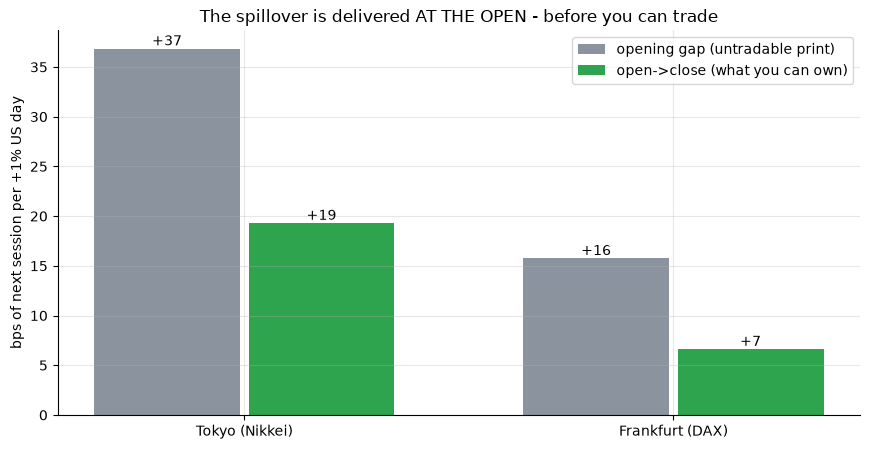

In [3]:
tks = ['^N225', '^GDAXI']   # the two markets with honestly recorded opens
if HAVE_REAL:
    rows = []
    for tk in tks:
        s = st.market_summary(PAIRS[tk])
        rows.append((s['gap']['slope'], s['oc']['slope']))
else:
    rows = [(R['mech'][tk][0], R['mech'][tk][3]) for tk in tks]
x = np.arange(len(tks))
fig, ax = plt.subplots(figsize=(8.8, 4.6))
ax.bar(x-.18, [r[0]*100 for r in rows], .34, color=GREY, label='opening gap (untradable print)')
ax.bar(x+.18, [r[1]*100 for r in rows], .34, color=GREEN, label='open->close (what you can own)')
for i, r in enumerate(rows):
    ax.annotate(f'{r[0]*100:+.0f}', (i-.18, r[0]*100), ha='center', va='bottom')
    ax.annotate(f'{r[1]*100:+.0f}', (i+.18, r[1]*100), ha='center', va='bottom')
ax.set_xticks(x); ax.set_xticklabels(['Tokyo (Nikkei)', 'Frankfurt (DAX)'])
ax.set_ylabel('bps of next session per +1% US day')
ax.set_title('The spillover is delivered AT THE OPEN - before you can trade')
ax.legend(); plt.tight_layout(); plt.show()

There's the catch. In Tokyo, **66%** of the follow-through is in the opening print itself (the gap tracks the US day so tightly that knowing yesterday's S&P explains **38%** of the gap's variance — the Nikkei open is almost a *formula* applied to the US close). In Frankfurt it's **71%**. The market you're allowed to touch — open to close — keeps only a sliver.

**The only trade you can actually do:** know the US close (4pm ET), then buy (or short) the overseas market **at its open**, sell at its close, every day, and pay costs.

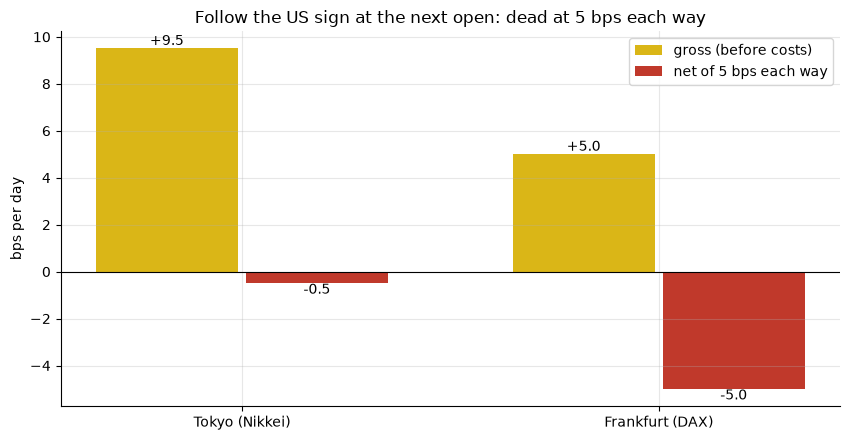

gross bps/day: [np.float64(9.5), np.float64(5.0)]  net@5bps: [np.float64(-0.5), np.float64(-5.0)]


In [4]:
tks = ['^N225', '^GDAXI']
if HAVE_REAL:
    g5 = [st.feasible_trade(PAIRS[tk], 5.0) for tk in tks]
    gross = [r['gross_bps'] for r in g5]; net5 = [r['net_bps'] for r in g5]
else:
    gross = [R['feasible'][tk][0] for tk in tks]; net5 = [R['feasible'][tk][3] for tk in tks]
x = np.arange(len(tks))
fig, ax = plt.subplots(figsize=(8.6, 4.5))
ax.bar(x-.18, gross, .34, color=AMBER, label='gross (before costs)')
ax.bar(x+.18, net5, .34, color=RED, label='net of 5 bps each way')
ax.axhline(0, c='k', lw=.8)
for i in range(len(tks)):
    ax.annotate(f'{gross[i]:+.1f}', (i-.18, gross[i]), ha='center', va='bottom')
    ax.annotate(f'{net5[i]:+.1f}', (i+.18, min(net5[i],0)), ha='center', va='top')
ax.set_xticks(x); ax.set_xticklabels(['Tokyo (Nikkei)', 'Frankfurt (DAX)'])
ax.set_ylabel('bps per day')
ax.set_title('Follow the US sign at the next open: dead at 5 bps each way')
ax.legend(); plt.tight_layout(); plt.show()
print('gross bps/day:', [round(v,1) for v in gross], ' net@5bps:', [round(v,1) for v in net5])

Gross, there *is* a residue after the open (**+9.5 bps/day** in Tokyo — markets don't absorb the US news at the bell with 100% precision). But it's a daily-turnover trade: at a modest **5 bps each way** it nets **-0.5 bps/day** in Tokyo and **-5.0** in Frankfurt. Nothing left.

And the two escape hatches are locked too:
- **The Sydney line that *looks* profitable** in our table is an accounting ghost — the ASX "open" is a 10-minute staggered auction, so the printed open still contains yesterday's prices for stocks that haven't opened yet. The "profit" is repricing you could never buy.
- **The US-listed wrappers (EWJ for Japan, EWG for Germany)** trade during *US* hours. By the time you can touch them, they've already moved with the US market — same day, no prediction left.

## 5 · The verdict

- **Signal — Real.** Tomorrow's overseas session follows today's US close with slopes of +0.22 to +0.56 (Tokyo the strongest), *t*-scores of 9–20, stable for 30 years. As real as market statistics get.
- **Tradability — Mirage.** Two-thirds of the move is in the opening print you cannot trade; the open-to-close residue dies at 5 bps each way; the accessible wrappers reprice contemporaneously. Prediction without a vehicle.
- **Survives the algo era? — Confirmed.** Post-2010 is as strong as pre-2010 (Tokyo got *stronger*). It persists precisely because there's no P&L in it — geography isn't an inefficiency.

## 6 · Going further 🚪

- **Why doesn't it decay like other anomalies?** Published *tradable* edges get eaten (McLean & Pontiff 2016). This one is *information flow*: the profit-shaped part (the gap) is captured by the opening auction itself. What's published can't decay if nobody can trade it.
- **The one that did decay is the exception that proves it:** London — the market whose session most overlaps New York's, where index futures arbitrage is densest — halved its slope after 2010. Overlap creates arbitrage; time-zone separation protects the pattern.
- **Build your own.** Swap in Korea, India or Brazil; or measure the gap slope against US *futures* moves during foreign hours. The engine (`us_leads_the_world/`) aligns any pair of calendars.

*Think you've found the after-the-open residue net of real costs — index futures at 1 bp, borrow paid on the short nights? Show the net line clearing zero with an honest open. Then we'll talk.*